In [ ]:
import os
import sys
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from tensorflow.keras import layers, models
from PIL import Image
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path
from torchvision import transforms
from torch.utils.data import Subset
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import callbacks
from tqdm.keras import TqdmCallback
from tensorflow.keras.models import load_model

sys.path.append(os.path.abspath(os.path.join("../..")))
from src.datasets.huggingfacedataset import HuggingFaceDataset

load_dotenv()

PROJECT_ROOT = Path(os.environ["PROJECT_ROOT_DIR"])
os.chdir(PROJECT_ROOT)

model_path = PROJECT_ROOT / "src/models/autoencoder/autoencoder_v1.keras"
autoencoder = load_model(model_path)

print("Model loaded successfully!")

Model loaded successfully!


In [67]:
autoencoder.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 40, 150, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 40, 150, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 40, 150, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 20, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 20, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 20, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 10, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Conv2D)           │ (None, 10, 38, 16)     │         9,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_14             │ (None, 20, 76, 64)     │         9,280 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 20, 76, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 20, 76, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (None, 40, 152, 32)    │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 40, 152, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d_6 (Cropping2D)       │ (None, 40, 150, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 40, 150, 1)     │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,525 (662.21 KB)

 Trainable params: 56,401 (220.32 KB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 112,804 (440.64 KB)

In [5]:
def load_image(path):
    path = tf.cast(path, tf.string)

    # Determine extension
    ext = tf.strings.lower(tf.strings.split(path, ".")[-1])

    # Decode depending on type
    def decode_jpeg(): return tf.image.decode_jpeg(tf.io.read_file(path), channels=3)
    def decode_png():  return tf.image.decode_png(tf.io.read_file(path), channels=3)

    img = tf.cond(tf.equal(ext, "png"), decode_png, decode_jpeg)

    # Convert to grayscale, resize, normalize
    img = tf.image.rgb_to_grayscale(img)
    img = tf.image.resize(img, [40, 150])
    img = img / 255.0

    return img

In [6]:
def build_dataset_subset(folder, n_images, extensions=(".jpg", ".png"), reverse=False, batch_size=64):
    """
    folder: Path to dataset
    n_images: number of images to take
    extensions: tuple of file extensions to include
    reverse: if True, takes images from the end
    """
    all_paths = [p for p in folder.rglob("*") if p.suffix.lower() in extensions]
    all_paths = sorted(all_paths)

    if reverse:
        all_paths = all_paths[-n_images:]  # last n_images
    else:
        all_paths = all_paths[:n_images]   # first n_images

    all_paths = [str(p) for p in all_paths]
    all_paths = tf.constant(all_paths)

    dataset = (
        tf.data.Dataset.from_tensor_slices(all_paths)
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    return dataset, len(all_paths)

In [8]:
captcha_dir = PROJECT_ROOT / "data/hammer_captchas"
cifar_dir   = PROJECT_ROOT / "data/cifar10"
svhn_dir    = PROJECT_ROOT / "data/svhn"

# Last 1,000 CAPTCHA images (.jpg)
# Take images from end because first 10,000 were used to train the model
captcha_dataset, captcha_count = build_dataset_subset(captcha_dir, 1000, extensions=(".jpg",), reverse=True)

# First 1,000 CIFAR10 images (.png)
cifar_dataset, cifar_count = build_dataset_subset(cifar_dir, 1000, extensions=(".png",), reverse=False)

# First 1,000 SVHN images (.png)
svhn_dataset, svhn_count = build_dataset_subset(svhn_dir, 1000, extensions=(".png",), reverse=False)

print("Captcha images:", captcha_count)
print("CIFAR images:", cifar_count)
print("SVHN images:", svhn_count)

Captcha images: 1000
CIFAR images: 1000
SVHN images: 1000


In [68]:
def reconstruction_error_bce(model, dataset):
    errors = []
    # Use the Keras BCE object with 'none' reduction to get per-pixel loss
    bce_fn = tf.keras.losses.BinaryCrossentropy(
        from_logits=False, 
        reduction=None
    )
    
    for batch in dataset:
        # 1. Get the model's reconstruction
        recon = model.predict(batch, verbose=0)
        
        # 2. Compute BCE for the whole batch
        # This returns a tensor of shape (batch_size, height, width)
        pixel_wise_bce = bce_fn(batch, recon)
        
        # 3. Average the error across the image dimensions (Height, Width)
        # to get one error value per image
        batch_error = tf.reduce_mean(pixel_wise_bce, axis=[1, 2]).numpy()
        
        errors.extend(batch_error)
        
    return np.array(errors)

In [83]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get reconstruction errors
captcha_errors = reconstruction_error_bce(autoencoder, captcha_dataset)
cifar_errors   = reconstruction_error_bce(autoencoder, cifar_dataset)
svhn_errors    = reconstruction_error_bce(autoencoder, svhn_dataset)

# Combine datasets
y_true = np.concatenate([
    np.zeros(len(captcha_errors)),      # CAPTCHA = 0 (Normal/Negative)
    np.ones(len(cifar_errors)),       # CIFAR = 1 (Anomaly/Positive)
    np.ones(len(svhn_errors))         # SVHN = 1 (Anomaly/Positive)
])

y_scores = np.concatenate([
    captcha_errors,
    cifar_errors,
    svhn_errors
])

roc_auc = roc_auc_score(y_true, y_scores)
print("ROC-AUC:", roc_auc)

2026-03-12 05:54:19.627442: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


ROC-AUC: 0.971102


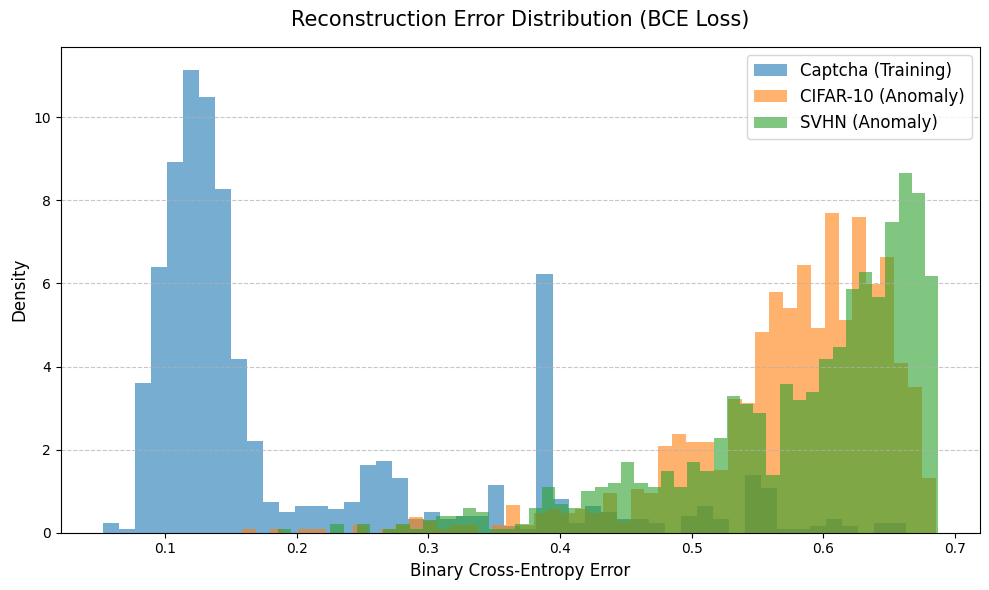

In [84]:
plt.figure(figsize=(10, 6))

# Plotting the histograms with alpha for transparency
plt.hist(captcha_errors, bins=50, alpha=0.6, label='Captcha (Training)', color='#1f77b4', density=True)
plt.hist(cifar_errors, bins=50, alpha=0.6, label='CIFAR-10 (Anomaly)', color='#ff7f0e', density=True)
plt.hist(svhn_errors, bins=50, alpha=0.6, label='SVHN (Anomaly)', color='#2ca02c', density=True)

# Add titles and labels
plt.title('Reconstruction Error Distribution (BCE Loss)', fontsize=15, pad=15)
plt.xlabel('Binary Cross-Entropy Error', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Adding a grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Make the legend clear
plt.legend(loc='upper right', fontsize=12)

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

In [87]:
def get_fpr_at_tpr(y_true, y_scores, target_tpr=0.95):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    idx = np.searchsorted(tpr, target_tpr)
    return fpr[idx]

# DO NOT USE NEGATIVE SIGNS HERE
# Your model is already producing HIGHER errors for CIFAR than for Captchas.

# CIFAR-10 Evaluation
y_true_cifar = np.concatenate([np.zeros(len(captcha_errors)), np.ones(len(cifar_errors))])
y_scores_cifar = np.concatenate([captcha_errors, cifar_errors])

# SVHN Evaluation
y_true_svhn = np.concatenate([np.zeros(len(captcha_errors)), np.ones(len(svhn_errors))])
y_scores_svhn = np.concatenate([captcha_errors, svhn_errors])

# Results
print(f"{'Metric':<30} | {'Value':<10}")
print("-" * 45)
print(f"{'ROC-AUC vs CIFAR-10':<30} | {roc_auc_score(y_true_cifar, y_scores_cifar):.4f}")
print(f"{'ROC-AUC vs SVHN':<30} | {roc_auc_score(y_true_svhn, y_scores_svhn):.4f}")
print(f"{'FPR@95TPR vs CIFAR-10':<30} | {get_fpr_at_tpr(y_true_cifar, y_scores_cifar):.4f}")
print(f"{'FPR@95TPR vs SVHN':<30} | {get_fpr_at_tpr(y_true_svhn, y_scores_svhn):.4f}")

Metric                         | Value     
---------------------------------------------
ROC-AUC vs CIFAR-10            | 0.9711
ROC-AUC vs SVHN                | 0.9711
FPR@95TPR vs CIFAR-10          | 0.0890
FPR@95TPR vs SVHN              | 0.1020
